# Figure 9: Annotations vs. CoCiP

This code will run CoCiP for all collocations in the final dataset. Running this the first time takes quite a while since all ERA5 weather data will be downloaded to your cache. I already downloaded this, and saved the data necessary data to `../data/contrail_evolution/`. To run this on other flights, uncomment the part where the CoCiP simulations are run. 

**Note:** you do need the full dataset downloaded to access the IAGOS flight information for running the CoCiP simulations. The full dataset is publicly available via the 4TU.ResearchData archive (see `../README.md`). Once you download the full dataset, assign the path to the `collocations` folder to the `DATASET_LOCATION` variable.  

In [8]:
import json
import os
import warnings
import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import image as mpimg
import seaborn as sns
import pyproj
from shapely.geometry import shape, mapping
from shapely.ops import transform

from pycontrails import Flight
from pycontrails.datalib import sentinel
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.datalib.leo_utils import correction
from pycontrails.models.cocip import Cocip
from pycontrails.models.humidity_scaling import ConstantHumidityScaling
from pycontrails.models.ps_model import PSFlight

from iagos_toolkit.weather.isa import get_p_ISA
from iagos_toolkit.flight.aircraft_performance import create_flight_from_iagos

In [9]:
# If you want to compute the CoCiP flight trajectories, assign the path to the `collocations` folder 
# to the `DATASET_LOCATION` variable.  
# For Windows users, use the Windows native path format e.g. DATASET_LOCATION=r'C:\...\collocations'
DATASET_LOCATION = "../codecheck/data/collocations/"

df = pd.read_csv('../data/landsat_sentinel_collocations_20260216.csv', comment='#')

In [10]:
df = df[df["air_temperature_iagos_validity"] <= 0]
df = df[df["rhl_iagos_validity"] <= 0]
df = df[df["contrail_formation"].notna()]
df = df[df["efficiency_PS_IAGOS"].notna()]

df = df[df["satellite"] == "Sentinel"]
df = df[df["contrail_formation"] == True]
df = df[df["contrail_label"].notna()]

print("Number of annotated cases in Sentinel-2:", len(df))

Number of annotated cases in Sentinel-2: 195


In [11]:
def round_pressure_levels(levels):
    supported_levels = np.array([
        1000, 975, 950, 925, 900, 875, 850, 825, 800, 775, 750,
        700, 650, 600, 550, 500, 450, 400, 350, 300, 250, 225,
        200, 175, 150, 125, 100, 70, 50, 30, 20, 10, 7, 5, 3, 2, 1, -1
    ])

    lower_bound = min(levels)
    lower_levels = supported_levels[supported_levels <= lower_bound]

    upper_bound = max(levels)
    upper_levels = supported_levels[supported_levels >= upper_bound]

    return [lower_levels.max(), upper_levels.min()]

In [12]:
def get_cocip_contrail(flight, target_time, window=[-10, 1], dt_integration=1, rh_scaling=0.99):
    # convert flight to dataframe
    flight_df = flight.dataframe

    # Define time window
    start_time = target_time + pd.Timedelta(minutes=window[0]) - pd.Timedelta(seconds=4) # subtract 4 seconds minute buffer
    end_time = target_time + pd.Timedelta(minutes=window[1]) + pd.Timedelta(minutes=1) # add 21 minute buffer after to avoid no Met error

    # Trim the flight
    flight_df_trimmed = flight_df[(flight_df["time"] >= start_time) & (flight_df["time"] <= end_time)].copy()
    flight_df_trimmed.reset_index(drop=True, inplace=True)

    flight_trimmed = Flight(flight_df_trimmed, attrs=flight.attrs).clean_and_resample("1s")
    
    # get meteorlogical data
    time_bounds = (flight_trimmed.time_start, flight_trimmed.time_end)
    pressure_levels = round_pressure_levels([get_p_ISA(flight_df_trimmed["altitude"].max()) / 100, get_p_ISA(flight_df_trimmed["altitude"].min()) / 100])

    era5pl = ERA5(
        time=time_bounds,
        variables=Cocip.met_variables + Cocip.optional_met_variables,
        pressure_levels=pressure_levels,
    )
    era5sl = ERA5(time=time_bounds, variables=Cocip.rad_variables)

    # download data from ERA5 (or open from cache)
    met = era5pl.open_metdataset()
    rad = era5sl.open_metdataset()

    params = {
        "dt_integration": np.timedelta64(dt_integration, "s"),
        "humidity_scaling": ConstantHumidityScaling(rhi_adj=rh_scaling),
        "aircraft_performance": PSFlight(),
        "max_age": pd.Timedelta(minutes=(-window[0] + window[1])),
    }
    cocip = Cocip(met=met, rad=rad, params=params)

    _ = cocip.eval(source=flight_trimmed)
    contrail_df = cocip.contrail
    if contrail_df is None or contrail_df.empty:
        return pd.DataFrame()  # Return empty DataFrame if no contrail data
    contrail_df = contrail_df[contrail_df["time"] == target_time]
    
    return contrail_df

In [13]:
for idx, row in tqdm(df.iterrows(), "Running CoCiP for all annotated contrails", total=len(df)):
    
    intersect_directory = DATASET_LOCATION + row["path"]
    print(intersect_directory)
    
    # Manually labelled aircraft location
    x_ac = row["x"]
    y_ac = row["y"]

    flight = create_flight_from_iagos(
        f"{intersect_directory}/{row['iagos_file']}", "A333"
    )
    target_time = pd.to_datetime(row["sensing_time"])
    target_time = target_time.round("1s").tz_localize(None)

    handler = sentinel.Sentinel(row["base_url"], row["scene_id"], bands=["B02", "B03", "B04"])
    
    # rh_scaling = 0.99  # Teoh value
    iagos_rh = row["rhi_iagos"]
    era5_rh = row["rhi_era5"]
    rh_scaling = era5_rh / iagos_rh   

    # clip between realistic values
    rh_scaling = max(0.7, min(rh_scaling, 1.3))

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
    
        cocip_df = get_cocip_contrail(flight, target_time, window=[-20, 1], rh_scaling=rh_scaling)

    if cocip_df.empty:
        cocip_df.to_csv(f"../codecheck/data/contrail_evolution/cocip/{row['scene_id']}_rh_variable.csv")
        continue

    # add the x and y coordinates of the contrail in the UTM coordinate system
    utm_crs = handler.get_crs()

    # Project from WGS84 to the x and y coordinates in the UTM coordinate system
    transformer = pyproj.Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
    x1, y1 = transformer.transform(cocip_df["longitude"], cocip_df["latitude"])
    z = cocip_df.altitude

    cocip_df.loc[:, "x"] = x1
    cocip_df.loc[:, "y"] = y1

    # Apply sensing angle correction
    ds_angles = handler.get_viewing_angle_metadata()
    x_proj, y_proj = correction.scan_angle_correction(ds_angles, x1, y1, z, maxiter=3)
    cocip_df.loc[:, "x_proj"] = x_proj
    cocip_df.loc[:, "y_proj"] = y_proj

    # print(f"Processed granule: {granule_id}. Found {len(cocip_df)} contrail points.")
    cocip_df.to_csv(f"../codecheck/data/contrail_evolution/cocip/{row['scene_id']}_rh_variable.csv")

Running CoCiP for all annotated contrails:   0%|          | 0/195 [00:00<?, ?it/s]

../codecheck/data/collocations/intersects_sentinel/2022/2022050908551904_L1C_T17TNJ_A035930_20220509T162807


Running CoCiP for all annotated contrails:   1%|          | 1/195 [00:03<11:12,  3.47s/it]

../codecheck/data/collocations/intersects_sentinel/2022/2022062908482306_L1C_T20TPP_A027750_20220629T150819


2026-07-10 15:20:01,763 INFO Request ID is 12cb1e8f-d77f-40f7-b484-629772061cca
2026-07-10 15:20:01,831 INFO status has been updated to accepted
2026-07-10 15:20:53,643 INFO status has been updated to running
2026-07-10 15:21:19,334 INFO status has been updated to successful


...

2026-07-10 21:28:23,408 INFO Request ID is 45a2a1c1-eed2-42da-a0ee-022769ab34ad
2026-07-10 21:28:23,471 INFO status has been updated to accepted
2026-07-10 21:28:44,563 INFO status has been updated to running
2026-07-10 21:28:56,011 INFO status has been updated to successful


372212959c14bad0639941cc466a0ecb.nc:   0%|          | 0.00/38.9M [00:00<?, ?B/s]

2026-07-10 21:29:04,381 INFO Request ID is 57fc4950-336b-41db-ba00-fa4598314bfa
2026-07-10 21:29:04,446 INFO status has been updated to accepted
2026-07-10 21:29:25,550 INFO status has been updated to running
2026-07-10 21:29:37,010 INFO status has been updated to successful


46e101815b4b96ccf33d873e462f4941.nc:   0%|          | 0.00/4.65M [00:00<?, ?B/s]

Running CoCiP for all annotated contrails: 100%|██████████| 195/195 [6:11:30<00:00, 114.31s/it]


---
## Plotting the figure

In [14]:
input_dir = "../codecheck/data/contrail_evolution/annotations"

contrails = {}

for filename in os.listdir(input_dir):

    if filename.endswith(".json"):
        scene_id = filename.replace(".json", "")
        
        with open(os.path.join(input_dir, filename)) as f:
            data = json.load(f)

        # Convert lists back to numpy arrays where needed
        for key in ["x", "y", "distance", "width", "age"]:
            if key in data:
                data[key] = np.array(data[key])

        contrails[scene_id] = data


Case 1 statistics:
  Slope (observations): 1.7018 m/s

Case 2 statistics:
  Slope (observations): 0.8202 m/s

Case 3 statistics:
  Slope (observations): 0.9332 m/s


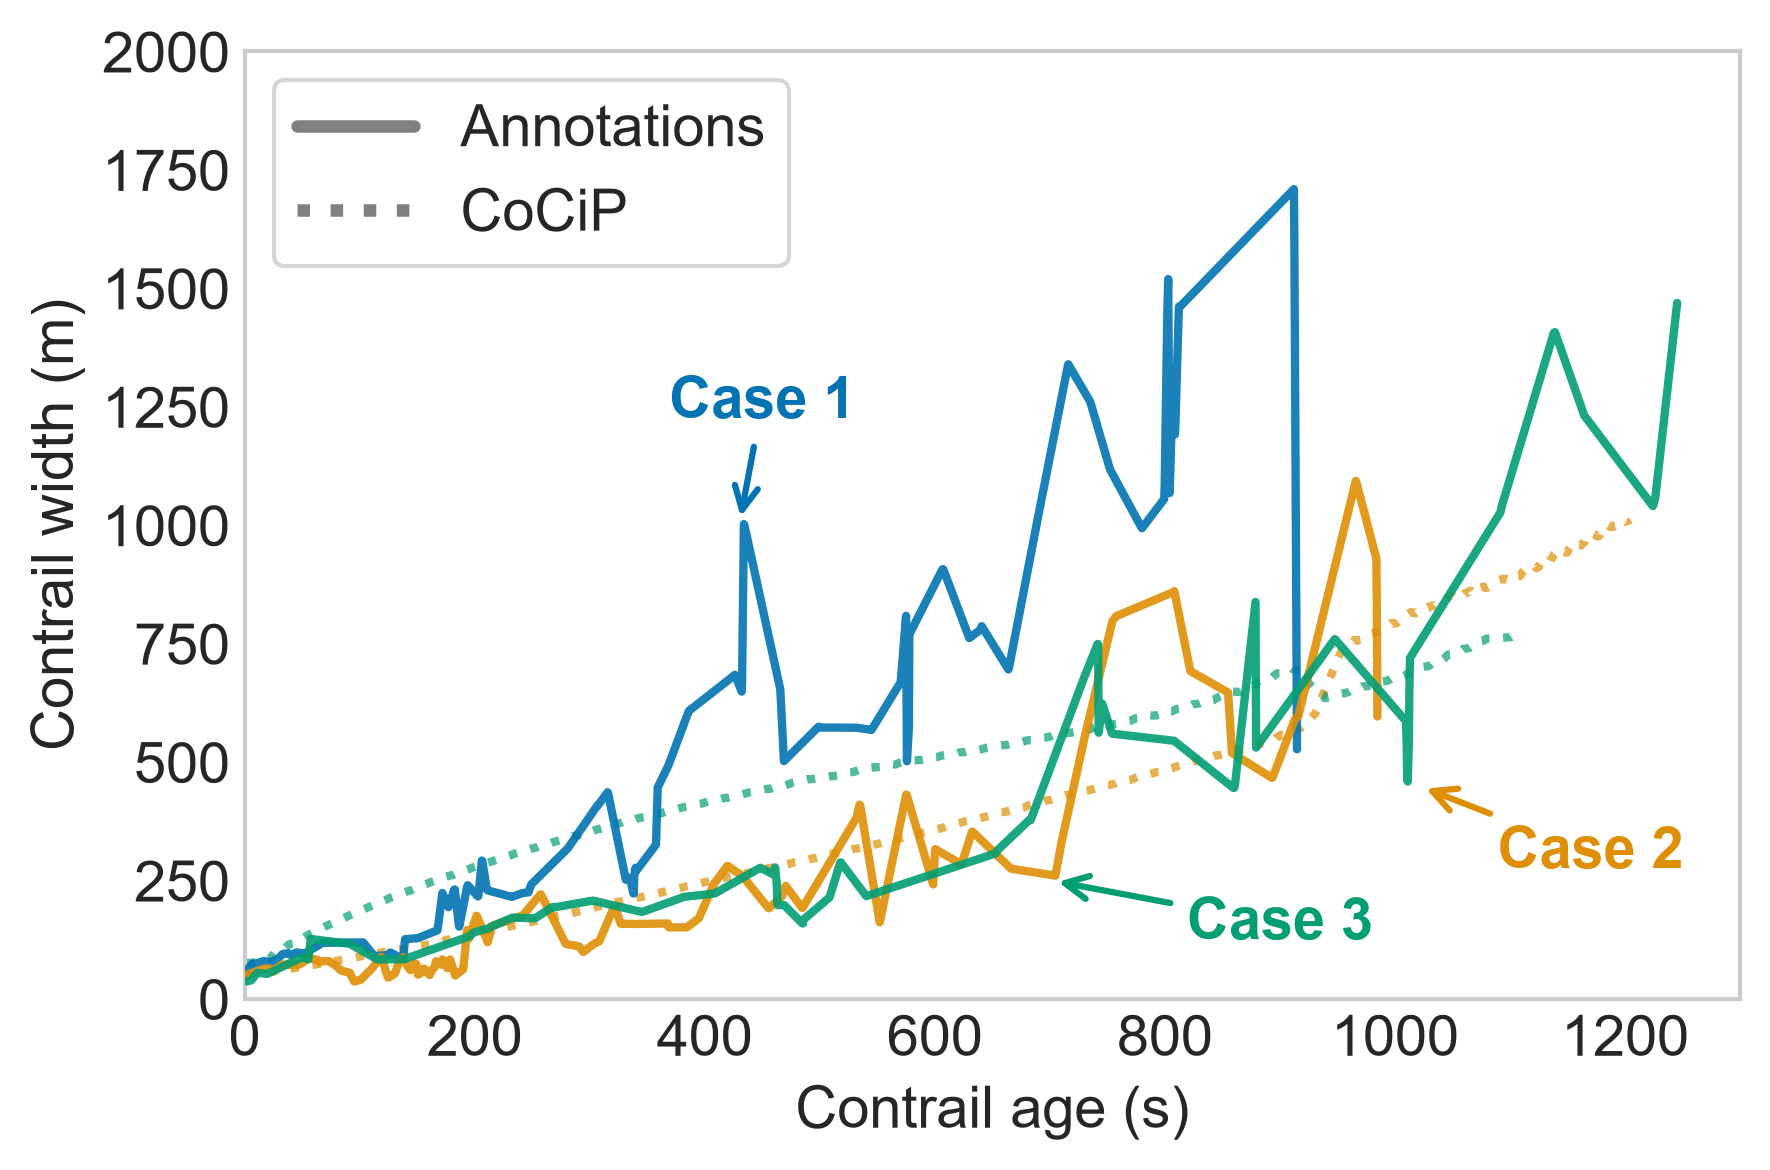

In [25]:
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

plt.style.use("seaborn-v0_8-whitegrid")  # Seaborn-like style without seaborn

window = 21  # smoothing window (must be odd)
case_colors = sns.color_palette("colorblind", 3)

color_cycle = itertools.cycle(case_colors)

annotation_locations = [
    [430, 1000, 450, 1200],
    [1020, 450, 1170, 250],
    [700, 250, 900, 100],
]

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

case_idx = 1

for d in contrails.values():
    # Only keep long-lived contrails
    if d["total_age"] <= 600:
        continue

    color = next(color_cycle)
    
    # Load CoCiP
    cocip = pd.read_csv(f"../codecheck/data/contrail_evolution/cocip/{d['scene_id']}_rh_variable.csv")
    cocip["age_seconds"] = pd.to_timedelta(cocip["age"]).dt.total_seconds().astype(int)
    cocip = cocip[cocip["age_seconds"] >= 1]
    cocip.sort_values("age_seconds", inplace=True)
    cocip["width_smooth"] = cocip["width"].rolling(window=window, center=True, min_periods=1).mean()

    # Observations
    annotation = pd.DataFrame({
        "age": pd.to_numeric(d["age"], errors="coerce"),
        "width": pd.to_numeric(d["width"], errors="coerce"),
    })

    # Drop NaNs
    annotation = annotation.dropna(subset=["width"]).sort_values("age")
    
    # Plot annotations
    ax.plot(
        annotation["age"],
        annotation["width"],
        color=color,
        linewidth=2,
        alpha=0.9,
        linestyle="-",
        zorder=3,
    )

    # Plot CoCiP 
    x = cocip["age_seconds"].values
    y = cocip["width_smooth"].values
    gap_mask = np.diff(x) > 100  # detect large gaps
    y_plot = y.astype(float).copy()
    y_plot[1:][gap_mask] = np.nan  # insert NaNs after gaps

    ax.plot(
        x,
        y_plot,
        color=color,
        linewidth=2.0,
        alpha=0.7,
        linestyle="dotted",
        zorder=2,
    )

    # Add annotation arrows
    ann = annotation_locations[case_idx - 1]
    ax.annotate(
        f"Case {case_idx}",
        xy=(ann[0], ann[1]),
        xytext=(ann[2], ann[3]),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
        fontsize=14,
        color=color,
        ha="center",
        va="bottom",
        fontweight="bold"
    )
    
    slope_ann, _ = np.polyfit(annotation["age"], annotation["width"], deg=1)
    #slope_cocip, _ = np.polyfit(cocip["age_seconds"], cocip["width_smooth"], deg=1)

    print(f"\nCase {case_idx} statistics:")
    print(f"  Slope (observations): {slope_ann:.4f} m/s")
    #print(f"  Slope (CoCiP):        {slope_cocip:.4f} m/s")

    case_idx += 1

# Add legend for line styles
ax.plot([], [], color="grey", linewidth=3, linestyle="-", label="Annotations")
ax.plot([], [], color="grey", linewidth=3, linestyle="dotted", label="CoCiP")

# Axis formatting
ax.set_xlabel("Contrail age (s)")
ax.set_ylabel("Contrail width (m)")
ax.set_xlim(0, 1300)
ax.set_ylim(0, 2000)
ax.legend(frameon=True, fontsize=14, loc="upper left")
ax.grid(False)
plt.tight_layout()
plt.savefig("../codecheck/figures/fig09_CoCiP.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()